In [79]:
import pandas as pd
import numpy as np
import os

file_path = "datasets/madalena_processed_30min"

def feature_engineer(file_path):
    df = pd.read_csv(file_path)
    df = df.loc[:, ~df.columns.str.startswith('Unnamed:')]    
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.set_index('timestamp', inplace=True)
    df = df.sort_index()
    df['day_of_year'] = df.index.dayofyear
    df['season'] = df.index.month % 12 // 3
    df['month'] = df.index.month
    df['day_of_week'] = df.index.weekday
    df['hour'] = df.index.hour
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 48)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 48)

    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['is_weekend'] = (df.index.weekday >= 5).astype(int)
    df['energy_lag_48'] = df['total_energy'].shift(48).fillna(method='bfill')
    df['energy_lag_96'] = df['total_energy'].shift(96).fillna(method='bfill')
    df['energy_lag_1'] = df['total_energy'].shift(1).fillna(method='bfill')
    df['energy_diff'] = df['total_energy'].diff().fillna(method='bfill')
    df['max_energy'] = df['total_energy'].rolling(window=48).max().fillna(method='bfill')
    df['min_energy'] = df['total_energy'].rolling(window=48).min().fillna(method='bfill')
    df['energy_diff_daily'] = df['max_energy'] - df['min_energy'] 
    df['energy_rolling'] = df['total_energy'].rolling(window=24).mean().fillna(method='bfill')
    df['Tout_diff'] = df['Tout'].diff().fillna(method="bfill")
    df['Tout_lag_1'] = df['Tout'].shift(1).fillna(method='bfill')
    df['Tout_lag_2'] = df['Tout'].shift(2).fillna(method='bfill')
    df['energy_std_48'] = df['total_energy'].rolling(window=48).std().fillna(method='bfill')
    df['energy_spike'] = (df['total_energy'] > df['total_energy'].rolling(window=48).mean().fillna(method='bfill') + 3*df['total_energy'].rolling(window=48).std().fillna(method='bfill')).astype(float)
    df['rolling_max_3h'] = df['total_energy'].rolling(window=6).max().fillna(method='bfill')
    return df

In [83]:
import torch
from torch.utils.data import TensorDataset, DataLoader


def create_mimo_sequences(data, spike_data, input_len=96, output_len=48):
    X, y, spike_targets = [], [], []
    for i in range(len(data) - input_len - output_len):
        X.append(data[i:i+input_len])
        y.append(data[i+input_len:i+input_len+output_len, 0]) 
        spike_targets.append(spike_data[i+input_len:i+input_len+output_len])
    return np.array(X), np.array(y), np.array(spike_targets)

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_17228\720081519.py:24: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_48'] = df['total_energy'].shift(48).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_17228\720081519.py:25: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_96'] = df['total_energy'].shift(96).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_17228\720081519.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_1'] = df['total_energy'].shift(1).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_17228\720081519.py:27: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use ob

Epoch 1, Loss: 0.7072
Epoch 2, Loss: 0.6472
Epoch 3, Loss: 0.6231
Epoch 4, Loss: 0.6166
Epoch 5, Loss: 0.6100
Epoch 6, Loss: 0.6018
Epoch 7, Loss: 0.5923
Epoch 8, Loss: 0.5805
Epoch 9, Loss: 0.5688
Epoch 10, Loss: 0.5536
Epoch 11, Loss: 0.5414
Epoch 12, Loss: 0.5285
Epoch 13, Loss: 0.5150
Epoch 14, Loss: 0.5047
Epoch 15, Loss: 0.4935
Epoch 16, Loss: 0.4826
Epoch 17, Loss: 0.4728
Epoch 18, Loss: 0.4647
Epoch 19, Loss: 0.4588
Epoch 20, Loss: 0.4519
Epoch 21, Loss: 0.4455
Epoch 22, Loss: 0.4394
Epoch 23, Loss: 0.4360
Epoch 24, Loss: 0.4335
Epoch 25, Loss: 0.4283
Epoch 26, Loss: 0.4283
Epoch 27, Loss: 0.4228
Epoch 28, Loss: 0.4204
Epoch 29, Loss: 0.4182
Epoch 30, Loss: 0.4147
Epoch 31, Loss: 0.4124
Epoch 32, Loss: 0.4109
Epoch 33, Loss: 0.4074
Epoch 34, Loss: 0.4047
Epoch 35, Loss: 0.4021
Epoch 36, Loss: 0.4029
Epoch 37, Loss: 0.4005
Epoch 38, Loss: 0.3961
Epoch 39, Loss: 0.3967
Epoch 40, Loss: 0.3932
Epoch 41, Loss: 0.3901
Epoch 42, Loss: 0.3894
Epoch 43, Loss: 0.3889
Epoch 44, Loss: 0.38

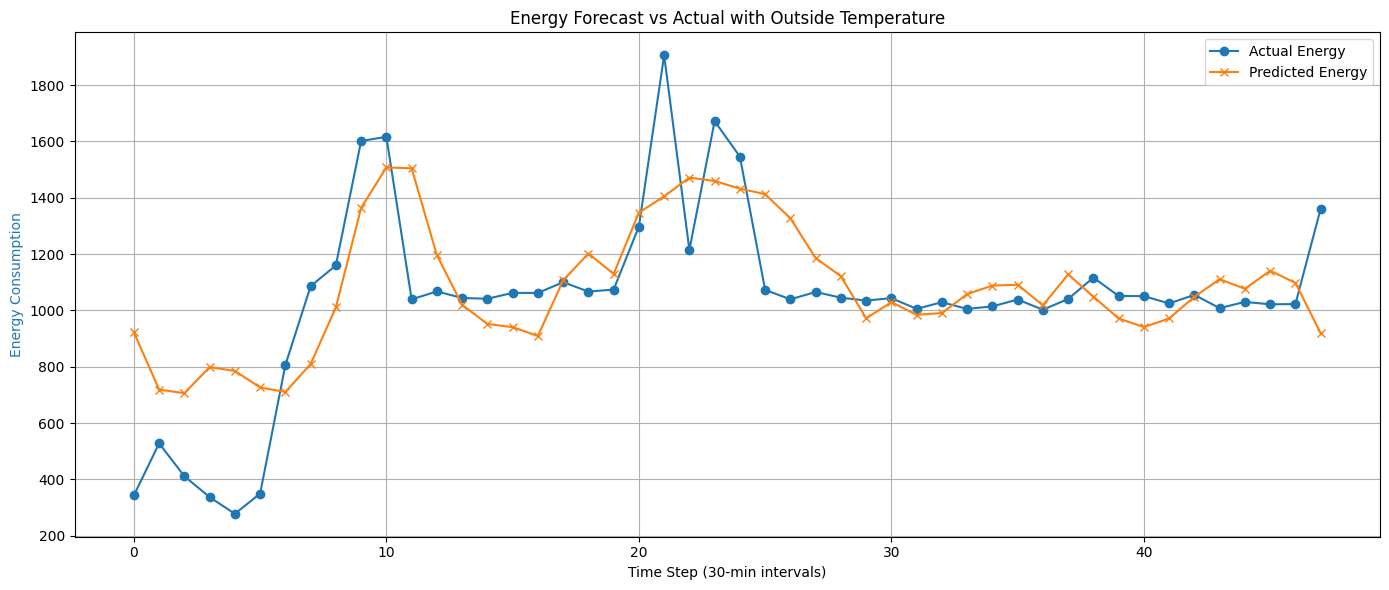

In [109]:
import torch.nn as nn
import matplotlib.pyplot as plt
import torch
import math
from sklearn.preprocessing import MinMaxScaler
import torch.nn.functional as F

class SpikeAwareLoss(nn.Module):
    # def __init__(self, spike_threshold=350,  spike_weight=2.5):
    #     super().__init__()
    #     # self.alpha = alpha
    #     # self.beta = beta
    #     # self.gamma = gamma
    #     self.spike_weight = spike_weight
    #     self.spike_threshold = spike_threshold
    #     self.spike_weight = spike_weight

    # def forward(self, pred, target):
    #     # mse = F.mse_loss(pred, target)

    #     mae = F.l1_loss(pred, target)
    #     # spike_diff = torch.abs(target[:, 1:] - target[:, :-1])
    #     # spike_mask = (spike_diff > 300).float()
    #     # target_mean = target.mean(dim=1, keepdim=True)
    #     # spike_mask = (target > target_mean).float()
    #     # spike_mse = ((1 + spike_mask * 4.0) * (pred - target) ** 4).mean()
    #     spike_mse = ( (pred - target) ** 4).mean()

    #     return mae + 4.0 * spike_mse
    def __init__(self, spike_weight=5.0):
        super().__init__()
        self.spike_weight = spike_weight

    def forward(self, pred, target, spike_mask):
        abs_error = torch.abs(pred - target)

        # Spike mask is 1 for spikes, 0 for non-spikes
        weights = 1 + (self.spike_weight - 1) * spike_mask

        weighted_mae = (weights * abs_error).mean()
        return weighted_mae

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)].to(x.device)
        return x

class CNNLSTM(nn.Module):
    def __init__(self, input_size, d_model=128, nhead=8, num_layers=2, output_len=48):
        super(CNNLSTM, self).__init__()
        self.cnn = nn.Conv1d(in_channels=input_size, out_channels=128, kernel_size=3, padding=1)
        # self.tcn = TCN(input_size=input_size, num_channels=[64, 128], kernel_size=3)
        # self.cnn = nn.Sequential(
        #     nn.Conv1d(in_channels=input_size, out_channels=64, kernel_size=3, padding=1),
        #     nn.ReLU(),
        #     nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
        #     nn.ReLU()
        # )
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Linear(64, output_len)
        )
        self.spike_fc = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Linear(64, output_len),
            nn.Sigmoid()
        )


    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        x = self.pos_encoder(x)
        x = self.transformer(x)  
        x_last = x[:, -1, :]        
        energy_pred = self.fc(x_last)
        spike_pred = self.spike_fc(x_last)
        return energy_pred, spike_pred

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


for file in os.listdir(file_path):
    full_path = os.path.join(file_path, file)
    if file != 'E_147.csv':
        continue
    df = feature_engineer(full_path)
    energy_diff = np.abs(df['total_energy'].values[1:] - df['total_energy'].values[:-1])
    spike_threshold = 300  
    spike_target = (energy_diff >= spike_threshold).astype(float)

    spike_target = np.concatenate([[0], spike_target])
    features = ['total_energy', 'Tout', 'energy_std_48', 'Tout_lag_2',
                'month_sin', 'month_cos', 'day_of_week', 'hour_sin','hour_cos', 'is_weekend', 'energy_lag_48', 'max_energy', 'Tout_diff', 'energy_spike']
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df[features])
    df[features] = scaled_data
    data = df[features].values

    X, y, spike_targets = create_mimo_sequences(data, spike_target)
    model = CNNLSTM(input_size=X.shape[2], d_model=128, output_len=48).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    spike_tensor = torch.tensor(spike_targets, dtype=torch.float32) 

    dataset = TensorDataset(X_tensor, y_tensor, spike_tensor)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

    for epoch in range(200):
        model.train()
        total_loss = 0
        for xb, yb, spike_target in train_loader:
            xb, yb, spike_target = xb.to(device), yb.to(device), spike_target.to(device)
            optimizer.zero_grad()
            energy_pred, spike_pred = model(xb)
            # energy_diff = torch.abs(yb[:, 1:] - yb[:, :-1])
            # spike_threshold = 350.0
            # spike_target = (energy_diff >= spike_threshold).float()
            # spike_target = torch.cat([torch.zeros((yb.size(0), 1), device=yb.device), spike_target], dim=1)
            criterion = SpikeAwareLoss()
            energy_loss = criterion(energy_pred, yb.to(device), spike_target)
            spike_loss = F.binary_cross_entropy(spike_pred, spike_target)
            loss = energy_loss + 1.5 * spike_loss
            loss.backward()
            # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb, spike_target in val_loader:
            xb = xb.to(device)
            # energy_pred, spike_pred = model(xb).cpu().numpy()
            energy_pred,spike = model(xb)
            energy_pred = energy_pred.cpu().numpy()
            all_preds.append(energy_pred)
            all_targets.append(yb.numpy())

    preds = np.concatenate(all_preds, axis=0)
    targets = np.concatenate(all_targets, axis=0)
    n_preds, n_steps = preds.shape
    n_features = len(features) 
    dummy = np.zeros((n_preds, n_steps, n_features - 1))
    preds_full = np.concatenate([preds[..., np.newaxis], dummy], axis=2) 
    targets_full = np.concatenate([targets[..., np.newaxis], dummy], axis=2)

    preds_flat = preds_full.reshape(-1, n_features)
    targets_flat = targets_full.reshape(-1, n_features)

    preds_inv = scaler.inverse_transform(preds_flat)[:, 0]   
    targets_inv = scaler.inverse_transform(targets_flat)[:, 0]

    preds = preds_inv.reshape(n_preds, n_steps)
    targets = targets_inv.reshape(n_preds, n_steps)

    mse = np.mean((preds - targets) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(preds - targets))

    print(f"✅ RMSE: {rmse:.4f}")
    print(f"✅ MAE:  {mae:.4f}")
    print(f"✅ MSE:  {mse:.4f}")
    sample_idx = 0  
    temperature_scaled = X_tensor[sample_idx, :, 1].numpy()
    dummy_temp = np.zeros((96, len(features)))
    dummy_temp[:, 1] = temperature_scaled 
    temp_inv = scaler.inverse_transform(dummy_temp)[:, 1]
    fig, ax1 = plt.subplots(figsize=(14, 6))
    steps = np.arange(48)

    plt.plot(steps, targets[sample_idx], label="Actual Energy", marker='o', color='tab:blue')
    plt.plot(steps, preds[sample_idx], label="Predicted Energy", marker='x', color='tab:orange')
    plt.ylabel("Energy Consumption", color='tab:blue')
    plt.xlabel("Time Step (30-min intervals)")
    # ax1.set_ylabel("Energy Consumption", color='tab:blue')
    # ax1.tick_params(axis='y', labelcolor='tab:blue')

    # ax2 = ax1.twinx()
    # ax2.plot(steps, temp_inv, label="Outside Temp (°C)", color='tab:green', linestyle='--')
    # ax2.set_ylabel("Temperature (°C)", color='tab:green')
    # ax2.tick_params(axis='y', labelcolor='tab:green')

    # lines, labels = ax1.get_legend_handles_labels()
    # lines2, labels2 = ax2.get_legend_handles_labels()
    # ax1.legend(lines + lines2, labels + labels2, loc='upper right')
    plt.legend()
    plt.title("Energy Forecast vs Actual with Outside Temperature")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    break


In [ ]:
# model.eval()
# latest_input = torch.tensor(X[-1:], dtype=torch.float32).to(device)
# with torch.no_grad():
#     forecast = model(latest_input).cpu().numpy().flatten()


✅ RMSE: 188.2641
✅ MAE:  113.3057
✅ MSE:  35443.3797


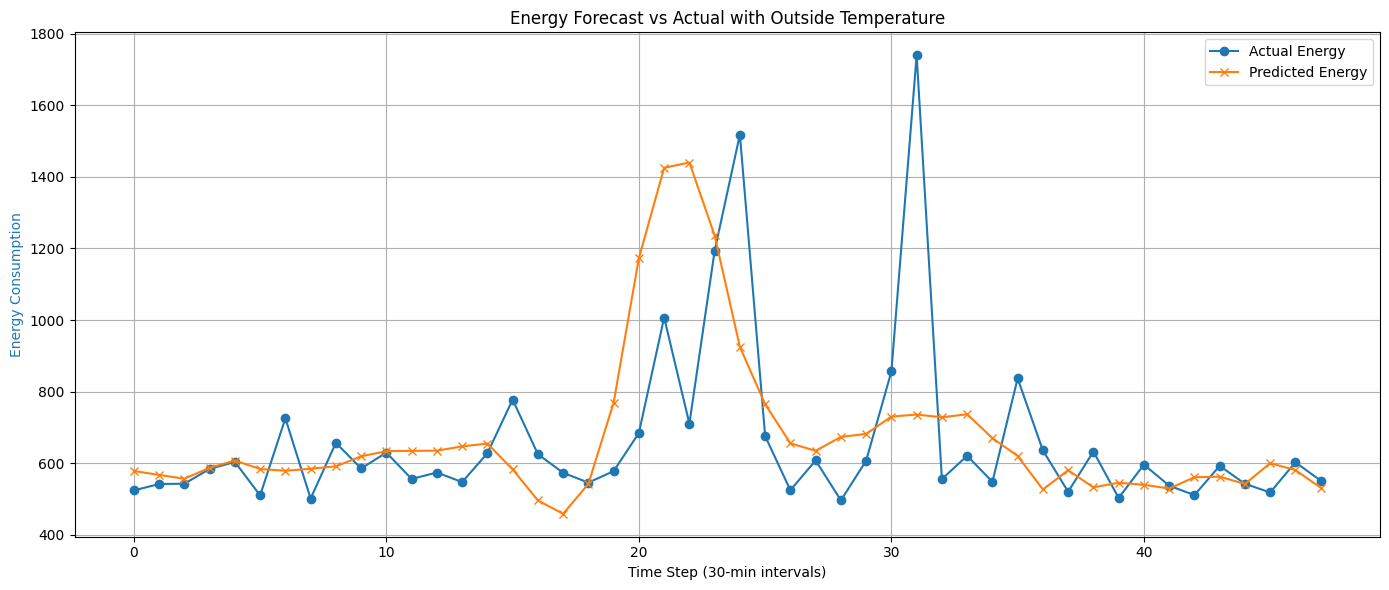

In [111]:
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
     with torch.no_grad():
        for xb, yb, spike_target in val_loader:
            xb = xb.to(device)
            # energy_pred, spike_pred = model(xb).cpu().numpy()
            energy_pred,spike = model(xb)
            energy_pred = energy_pred.cpu().numpy()
            all_preds.append(energy_pred)
            all_targets.append(yb.numpy())

    # for xb, yb in val_loader:
    #     xb = xb.to(device)
    #     energy_pred, spike_pred = model(xb)
    #     energy_pred = energy_pred.cpu().numpy()
    #     all_preds.append(energy_pred)
    #     all_targets.append(yb.numpy())

preds = np.concatenate(all_preds, axis=0)
targets = np.concatenate(all_targets, axis=0)
n_preds, n_steps = preds.shape
n_features = len(features) 
dummy = np.zeros((n_preds, n_steps, n_features - 1))
preds_full = np.concatenate([preds[..., np.newaxis], dummy], axis=2) 
targets_full = np.concatenate([targets[..., np.newaxis], dummy], axis=2)

preds_flat = preds_full.reshape(-1, n_features)
targets_flat = targets_full.reshape(-1, n_features)

preds_inv = scaler.inverse_transform(preds_flat)[:, 0]   
targets_inv = scaler.inverse_transform(targets_flat)[:, 0]

preds = preds_inv.reshape(n_preds, n_steps)
targets = targets_inv.reshape(n_preds, n_steps)

mse = np.mean((preds - targets) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(preds - targets))

print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ MAE:  {mae:.4f}")
print(f"✅ MSE:  {mse:.4f}")
sample_idx = 10
temperature_scaled = X_tensor[sample_idx, :, 1].numpy()
dummy_temp = np.zeros((96, len(features)))
dummy_temp[:, 1] = temperature_scaled 
temp_inv = scaler.inverse_transform(dummy_temp)[:, 1]
fig, ax1 = plt.subplots(figsize=(14, 6))
steps = np.arange(48)

plt.plot(steps, targets[sample_idx], label="Actual Energy", marker='o', color='tab:blue')
plt.plot(steps, preds[sample_idx], label="Predicted Energy", marker='x', color='tab:orange')
plt.ylabel("Energy Consumption", color='tab:blue')
plt.xlabel("Time Step (30-min intervals)")
# ax1.set_ylabel("Energy Consumption", color='tab:blue')
# ax1.tick_params(axis='y', labelcolor='tab:blue')

# ax2 = ax1.twinx()
# ax2.plot(steps, temp_inv, label="Outside Temp (°C)", color='tab:green', linestyle='--')
# ax2.set_ylabel("Temperature (°C)", color='tab:green')
# ax2.tick_params(axis='y', labelcolor='tab:green')

# lines, labels = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines + lines2, labels + labels2, loc='upper right')
plt.legend()
plt.title("Energy Forecast vs Actual with Outside Temperature")
plt.grid(True)
plt.tight_layout()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (48,) and (336,)

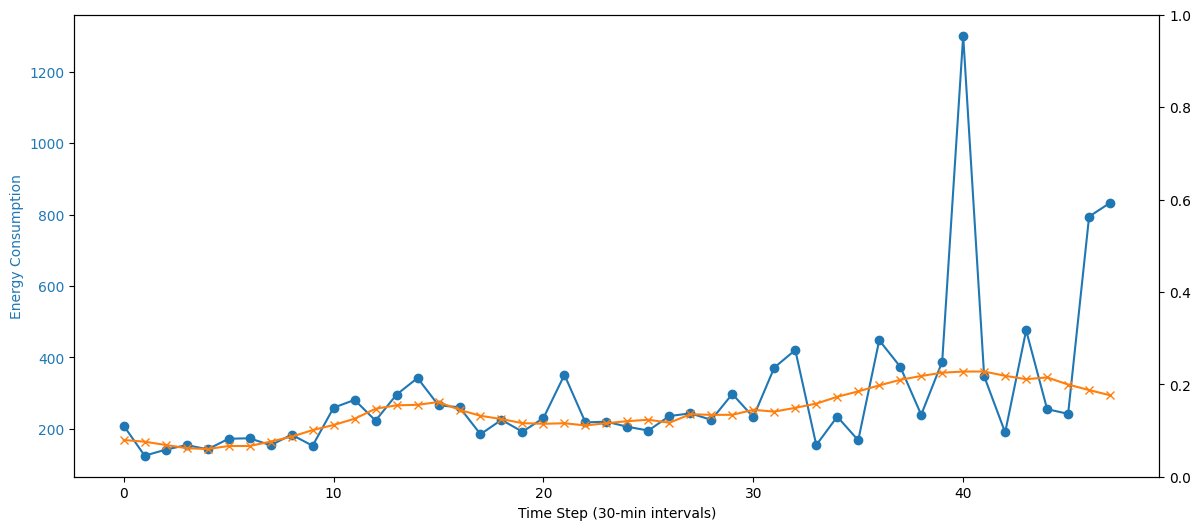

In [54]:
sample_idx = 3
 
temperature_scaled = X_tensor[sample_idx, :, 1].numpy()
dummy_temp = np.zeros((336, len(features)))
dummy_temp[:, 1] = temperature_scaled 
temp_inv = scaler.inverse_transform(dummy_temp)[:, 1]
fig, ax1 = plt.subplots(figsize=(14, 6))
steps = np.arange(48)

ax1.plot(steps, targets[sample_idx], label="Actual Energy", marker='o', color='tab:blue')
ax1.plot(steps, preds[sample_idx], label="Predicted Energy", marker='x', color='tab:orange')
ax1.set_xlabel("Time Step (30-min intervals)")
ax1.set_ylabel("Energy Consumption", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(steps, temp_inv, label="Outside Temp (°C)", color='tab:green', linestyle='--')
ax2.set_ylabel("Temperature (°C)", color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

plt.title("Energy Forecast vs Actual with Outside Temperature")
plt.grid(True)
plt.tight_layout()
plt.show()